# Klasyfikacja - Logistic Regression

### Analiza modelu:
1. [Import bibliotek](#0)
2. [Wprowadzenie do modelu](#1)
3. [Strategia balansowania](#2)
4. [Analiza dla datasetu Mushroom](#3)
5. [Analiza dla datasetu Adult Income](#4)
6. [Porownanie wynikow](#5)
7. [Wnioski koncowe](#6)


### <a name='0'></a> Import bibliotek

W notebooku wykorzystujemy wspolny pipeline przygotowania danych,
aby porownanie tego samego algorytmu na dwoch datasetach bylo uczciwe.


In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from mushroom_analysis import (
    TARGET_COLUMN,
    BernoulliNB,
    DecisionTreeClassifier,
    KNeighborsClassifier,
    LogisticRegression,
    RANDOM_STATE,
    RandomForestClassifier,
    class_balance_table,
    evaluate_models,
    load_data,
    load_dataset,
    missing_values_table,
    oversample_minority_class,
    plot_class_distribution,
    plot_confusion_matrix_for_model,
    plot_feature_histograms,
    plot_top_feature_correlations,
    preprocess_after_split,
    split_dataset,
)


### <a name='1'></a> Wprowadzenie do modelu


Logistic Regression jest jednym z podstawowych modeli klasyfikacji binarnej.
Mimo nazwy zawierajacej slowo "regression", model ten sluzy do przewidywania
prawdopodobienstwa przynaleznosci do klasy. W problemie klasyfikacji grzybow
model ten pozwala oszacowac, czy obiekt nalezy do klasy jadalnej czy trujacej.

Zaletami Logistic Regression sa:
- prostota interpretacji,
- szybki trening,
- dobra skutecznosc przy dobrze przygotowanych danych.


### <a name='2'></a> Strategia balansowania


W przypadku Logistic Regression zastosowano parametr `class_weight="balanced"`.
Jest to rozwiazanie odpowiednie dla modelu liniowego, poniewaz pozwala
uwzglednic drobne roznice w liczebnosci klas bez potrzeby duplikowania obserwacji.


### <a name='3'></a> Analiza dla datasetu Mushroom

Najpierw uruchamiamy ten sam algorytm na zbiorze mushroom.
Pozwoli to sprawdzic, czy model nadal osiaga niemal idealne wyniki
na bardzo dobrze separowalnym problemie klasyfikacyjnym.


In [2]:
df = load_dataset("mushroom")
train_df, validation_df, test_df = split_dataset(df)
preprocessed = preprocess_after_split(train_df, validation_df, test_df)

X_train_reference = preprocessed['X_train_model']
y_train_reference = preprocessed["y_train"]
X_validation_reference = preprocessed['X_validation_model']
X_test_reference = preprocessed['X_test_model']

print("Dataset:", "mushroom")
print("Shape:", df.shape)


Dataset: mushroom
Shape: (8124, 23)


#### Definicja modelu


In [3]:
model = LogisticRegression(
    max_iter=1500,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
model


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [4]:
model.fit(X_train_reference, y_train_reference)

validation_pred = model.predict(X_validation_reference)
test_pred = model.predict(X_test_reference)

metrics_df = pd.DataFrame(
    [
        {
            "split": "validation",
            "accuracy": round(accuracy_score(preprocessed["y_validation"], validation_pred), 4),
            "precision": round(precision_score(preprocessed["y_validation"], validation_pred), 4),
            "recall": round(recall_score(preprocessed["y_validation"], validation_pred), 4),
            "f1": round(f1_score(preprocessed["y_validation"], validation_pred), 4),
        },
        {
            "split": "test",
            "accuracy": round(accuracy_score(preprocessed["y_test"], test_pred), 4),
            "precision": round(precision_score(preprocessed["y_test"], test_pred), 4),
            "recall": round(recall_score(preprocessed["y_test"], test_pred), 4),
            "f1": round(f1_score(preprocessed["y_test"], test_pred), 4),
        },
    ]
)
metrics_df


,split,accuracy,precision,recall,f1
0,validation,0.9992,1.0,0.9983,0.9991
1,test,0.9992,1.0,0.9983,0.9991


In [5]:
mushroom_metrics = metrics_df.copy()
mushroom_metrics


,split,accuracy,precision,recall,f1
0,validation,0.9992,1.0,0.9983,0.9991
1,test,0.9992,1.0,0.9983,0.9991


In [6]:
validation_row = metrics_df[metrics_df["split"] == "validation"].iloc[0]
test_row = metrics_df[metrics_df["split"] == "test"].iloc[0]

print(
    f"Wnioski dla mushroom: validation F1 = {validation_row['f1']:.4f}, "
    f"test F1 = {test_row['f1']:.4f}, validation accuracy = {validation_row['accuracy']:.4f}, "
    f"test accuracy = {test_row['accuracy']:.4f}."
)


Wnioski dla mushroom: validation F1 = 0.9991, test F1 = 0.9991, validation accuracy = 0.9992, test accuracy = 0.9992.


#### Macierz pomylek i raport klasyfikacji


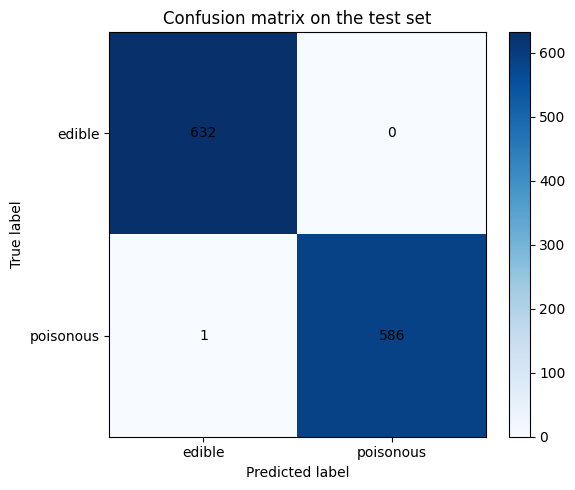

,precision,recall,f1-score,support
edible,0.998420,1.000000,0.999209,632.00000
poisonous,1.000000,0.998296,0.999147,587.00000
accuracy,0.999180,0.999180,0.999180,0.99918
macro avg,0.999210,0.999148,0.999178,1219.00000
weighted avg,0.999181,0.999180,0.999180,1219.00000


In [7]:
mushroom_classification_report = plot_confusion_matrix_for_model(
    model,
    X_test_reference,
    preprocessed["y_test"],
    preprocessed["label_encoder"],
)
mushroom_classification_report


### <a name='4'></a> Analiza dla datasetu Adult Income

Nastepnie uruchamiamy ten sam algorytm na bardziej wymagajacym
zewnetrznym datasecie Adult Income. Ten zbior zawiera cechy mieszane
i jest znacznie mniej separowalny niz mushroom.


In [8]:
df = load_dataset("adult_income")
train_df, validation_df, test_df = split_dataset(df)
preprocessed = preprocess_after_split(train_df, validation_df, test_df)

X_train_reference = preprocessed['X_train_model']
y_train_reference = preprocessed["y_train"]
X_validation_reference = preprocessed['X_validation_model']
X_test_reference = preprocessed['X_test_model']

print("Dataset:", "adult_income")
print("Shape:", df.shape)


Dataset: adult_income
Shape: (32561, 15)


#### Definicja modelu


In [9]:
model = LogisticRegression(
    max_iter=1500,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
model


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [10]:
model.fit(X_train_reference, y_train_reference)

validation_pred = model.predict(X_validation_reference)
test_pred = model.predict(X_test_reference)

metrics_df = pd.DataFrame(
    [
        {
            "split": "validation",
            "accuracy": round(accuracy_score(preprocessed["y_validation"], validation_pred), 4),
            "precision": round(precision_score(preprocessed["y_validation"], validation_pred), 4),
            "recall": round(recall_score(preprocessed["y_validation"], validation_pred), 4),
            "f1": round(f1_score(preprocessed["y_validation"], validation_pred), 4),
        },
        {
            "split": "test",
            "accuracy": round(accuracy_score(preprocessed["y_test"], test_pred), 4),
            "precision": round(precision_score(preprocessed["y_test"], test_pred), 4),
            "recall": round(recall_score(preprocessed["y_test"], test_pred), 4),
            "f1": round(f1_score(preprocessed["y_test"], test_pred), 4),
        },
    ]
)
metrics_df


,split,accuracy,precision,recall,f1
0,validation,0.8120,0.5726,0.8656,0.6892
1,test,0.8039,0.5610,0.8520,0.6766


In [11]:
adult_metrics = metrics_df.copy()
adult_metrics


,split,accuracy,precision,recall,f1
0,validation,0.8120,0.5726,0.8656,0.6892
1,test,0.8039,0.5610,0.8520,0.6766


In [12]:
validation_row = metrics_df[metrics_df["split"] == "validation"].iloc[0]
test_row = metrics_df[metrics_df["split"] == "test"].iloc[0]

print(
    f"Wnioski dla adult_income: validation F1 = {validation_row['f1']:.4f}, "
    f"test F1 = {test_row['f1']:.4f}, validation accuracy = {validation_row['accuracy']:.4f}, "
    f"test accuracy = {test_row['accuracy']:.4f}."
)


Wnioski dla adult_income: validation F1 = 0.6892, test F1 = 0.6766, validation accuracy = 0.8120, test accuracy = 0.8039.


#### Macierz pomylek i raport klasyfikacji


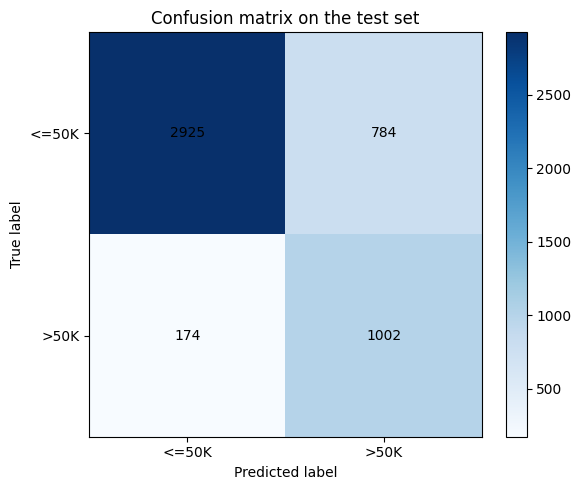

,precision,recall,f1-score,support
<=50K,0.943853,0.788622,0.859283,3709.000000
>50K,0.561030,0.852041,0.676570,1176.000000
accuracy,0.803889,0.803889,0.803889,0.803889
macro avg,0.752442,0.820332,0.767927,4885.000000
weighted avg,0.851693,0.803889,0.815297,4885.000000


In [13]:
adult_classification_report = plot_confusion_matrix_for_model(
    model,
    X_test_reference,
    preprocessed["y_test"],
    preprocessed["label_encoder"],
)
adult_classification_report


### <a name='5'></a> Porownanie wynikow

W tej sekcji zestawiamy wyniki jednego algorytmu
na dwoch roznych datasetach.


In [14]:
comparison_df = pd.DataFrame(
    [
        {
            "dataset": "mushroom",
            "validation_accuracy": mushroom_metrics[mushroom_metrics["split"] == "validation"].iloc[0]["accuracy"],
            "validation_f1": mushroom_metrics[mushroom_metrics["split"] == "validation"].iloc[0]["f1"],
            "test_accuracy": mushroom_metrics[mushroom_metrics["split"] == "test"].iloc[0]["accuracy"],
            "test_f1": mushroom_metrics[mushroom_metrics["split"] == "test"].iloc[0]["f1"],
        },
        {
            "dataset": "adult_income",
            "validation_accuracy": adult_metrics[adult_metrics["split"] == "validation"].iloc[0]["accuracy"],
            "validation_f1": adult_metrics[adult_metrics["split"] == "validation"].iloc[0]["f1"],
            "test_accuracy": adult_metrics[adult_metrics["split"] == "test"].iloc[0]["accuracy"],
            "test_f1": adult_metrics[adult_metrics["split"] == "test"].iloc[0]["f1"],
        },
    ]
)
comparison_df


,dataset,validation_accuracy,validation_f1,test_accuracy,test_f1
0,mushroom,0.9992,0.9991,0.9992,0.9991
1,adult_income,0.8120,0.6892,0.8039,0.6766


In [15]:
mushroom_row = comparison_df[comparison_df["dataset"] == "mushroom"].iloc[0]
adult_row = comparison_df[comparison_df["dataset"] == "adult_income"].iloc[0]

print(
    f"Wnioski koncowe dla Logistic Regression: model osiagnal na mushroom test F1 = "
    f"{mushroom_row['test_f1']:.4f}, natomiast na adult_income test F1 = "
    f"{adult_row['test_f1']:.4f}. Oznacza to, ze mushroom jest datasetem "
    f"znacznie latwiejszym, a adult_income stanowi bardziej wymagajacy problem klasyfikacyjny."
)


Wnioski koncowe dla Logistic Regression: model osiagnal na mushroom test F1 = 0.9991, natomiast na adult_income test F1 = 0.6766. Oznacza to, ze mushroom jest datasetem znacznie latwiejszym, a adult_income stanowi bardziej wymagajacy problem klasyfikacyjny.


### <a name='6'></a> Wnioski koncowe


Logistic Regression okazala sie bardzo skutecznym modelem dla zbioru mushroom.
Oznacza to, ze po odpowiednim zakodowaniu cech problem jest w duzym stopniu
liniowo separowalny. Model ten moze byc traktowany jako bardzo mocny punkt odniesienia
dla bardziej zlozonych algorytmow.
